In [1]:
# !pip install opencv-python
# !pip install pandas
# !pip install matplotlib
# !pip install urllib
!pip install scikit-learn

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import io # Input/Output Module
import os # OS interfaces
import cv2 # OpenCV package
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

from urllib import request # module for opening HTTP requests
from matplotlib import pyplot as plt # Plotting library
from sklearn.decomposition import PCA

<div style="width:100%; height:140px">
    <img src="https://www.kuleuven.be/internationaal/thinktank/fotos-en-logos/ku-leuven-logo.png/image_preview" width = auto, heigh = 200px align=left>
</div>


KUL H02A5a Computer Vision: Group Assignment 1
---------------------------------------------------------------
<div style="height:50px"></div>

<span style="color:red">**TODO**: Add your names below.</span>

<span style="color:red">**TODO**: Change the notebook name by replacing the X with your actual group number.</span>

Student names: <span style="color:red">name1, name2, ...</span>.

The goal of this assignment is to explore more advanced techniques for constructing features that better describe objects of interest and to perform face recognition using these features. This assignment will be delivered in groups of 5 (either composed by you or randomly assigned by your TA's).

---------------------------------------------------------------
This notebook is structured as follows:

0. Data loading & Preprocessing
1. Feature Representations
2. Evaluation Metrics 
3. Classifiers
4. Experiments
5. Publishing best results
6. Discussion

Make sure that your notebook is **self-contained** and **fully documented**. Provide strong arguments for the design choices that you made and what insights you got from your experiments. Make use of the *Group assignment 1* forum/discussion board on Toledo if you have any questions.

Good luck! 


<div class="alert alert-block alert-info">
<b>NOTE:</b> This notebook is just a example/template, feel free to adjust in any way you please! Just keep things organised and document accordingly!
</div>

<div class="alert alert-block alert-info">
<b>NOTE:</b> Clearly indicate the improvements that you make!!! You can for instance use titles like: <i>3.1. Improvement: Non-linear SVM with RBF Kernel.<i>
</div>
    
---------------------------------------------------------------
# 0. Data loading & Preprocessing

## 0.1. Loading data
The training set is many times smaller than the test set and this might strike you as odd, however, this is close to a real world scenario where your system might be put through daily use! In this session we will try to do the best we can with the data that we've got! 

In [3]:
# Input data files are available in the read-only "../input/" directory

train = pd.read_csv(
    './kul-computer-vision-ga-1-2026/train_set.csv', index_col = 0)
train.index = train.index.rename('id')

test = pd.read_csv(
    './kul-computer-vision-ga-1-2026/test_set.csv', index_col = 0)
test.index = test.index.rename('id')

# read the images as numpy arrays and store in "img" column
train['img'] = [cv2.cvtColor(np.load('./kul-computer-vision-ga-1-2026/train/train_{}.npy'.format(index), allow_pickle=False), cv2.COLOR_BGR2RGB) 
                for index, row in train.iterrows()]

test['img'] = [cv2.cvtColor(np.load('./kul-computer-vision-ga-1-2026/test/test_{}.npy'.format(index), allow_pickle=False), cv2.COLOR_BGR2RGB) 
                for index, row in test.iterrows()]
  

train_size, test_size = len(train),len(test)

"The training set contains {} examples, the test set contains {} examples.".format(train_size, test_size)

'The training set contains 80 examples, the test set contains 1816 examples.'

*Note: this dataset is a subset of the* [*VGG face dataset*](https://www.robots.ox.ac.uk/~vgg/data/vgg_face/).

## 0.2. A first look
Let's have a look at the data columns and class distribution.

In [4]:
# The training set contains an identifier, name, image information and class label
train.head(1)

,name,class,img
id,,,
0,Mila_Kunis,2,"[[[50, 31, 25], [49, 30, 24], [49, 30, 24], [4..."


In [5]:
# The test set only contains an identifier and corresponding image information.

test.head(1)

,img
id,
0,"[[[209, 210, 205], [208, 209, 204], [208, 209,..."


In [6]:
# The class distribution in the training set:
train.groupby('name').agg({'img':'count', 'class': 'max'})

,img,class
name,,
Jesse_Eisenberg,30,1
Michael_Cera,10,0
Mila_Kunis,30,2
Sarah_Hyland,10,0


Note that **Jesse is assigned the classification label 1**, and **Mila is assigned the classification label 2**. The dataset also contains 20 images of **look alikes (assigned classification label 0)** and the raw images. 

## 0.3. Preprocess data
### 0.3.1 Example: HAAR face detector
In this example we use the [HAAR feature based cascade classifiers](https://opencv-python-tutroals.readthedocs.io/en/latest/py_tutorials/py_objdetect/py_face_detection/py_face_detection.html) to detect faces, then the faces are resized so that they all have the same shape. If there are multiple faces in an image, we only take the first one. 

<div class="alert alert-block alert-info"> <b>NOTE:</b> You can write temporary files to <code>/kaggle/temp/</code> or <code>../../tmp</code>, but they won't be saved outside of the current session
</div>


In [7]:
class HAARPreprocessor():
    """Preprocessing pipeline built around HAAR feature based cascade classifiers. """
    
    def __init__(self, path, face_size):
        self.face_size = face_size
        file_path = os.path.join(path, "haarcascade_frontalface_default.xml")
        if not os.path.exists(file_path): 
            if not os.path.exists(path):
                os.mkdir(path)
            self.download_model(file_path)
        
        self.classifier = cv2.CascadeClassifier(file_path)
  
    def download_model(self, path):
        url = "https://raw.githubusercontent.com/opencv/opencv/master/data/"\
            "haarcascades/haarcascade_frontalface_default.xml"
        
        with request.urlopen(url) as r, open(path, 'wb') as f:
            f.write(r.read())
            
    def detect_faces(self, img):
        """Detect all faces in an image."""
        
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        return self.classifier.detectMultiScale(
            img_gray,
            scaleFactor=1.2,
            minNeighbors=5,
            minSize=(30, 30),
            flags=cv2.CASCADE_SCALE_IMAGE
        )
        
    def extract_faces(self, img):
        """Returns all faces (cropped) in an image."""
        
        faces = self.detect_faces(img)

        return [img[y:y+h, x:x+w] for (x, y, w, h) in faces]
    
    def preprocess(self, data_row):
        faces = self.extract_faces(data_row['img'])
        
        # if no faces were found, return None
        if len(faces) == 0:
            nan_img = np.empty(self.face_size + (3,))
            nan_img[:] = np.nan
            return nan_img
        
        # only return the first face
        return cv2.resize(faces[0], self.face_size, interpolation = cv2.INTER_AREA)
            
    def __call__(self, data):
        return np.stack([self.preprocess(row) for _, row in data.iterrows()]).astype(int)

**Visualise**

Let's plot a few examples.

In [8]:
# parameter to play with 
FACE_SIZE = (100, 100)

def plot_image_sequence(data, n, imgs_per_row=7, plot_gray = False):
    n_rows = 1 + int(n/(imgs_per_row+1))
    n_cols = min(imgs_per_row, n)

    f,ax = plt.subplots(n_rows,n_cols, figsize=(10*n_cols,10*n_rows))
    for i in range(n):
        if n == 1:
            if(plot_gray):
                ax.imshow(data[i], cmap = 'gray')
            else:
                ax.imshow(data[i])
        elif n_rows > 1:
            if(plot_gray):
                ax[int(i/imgs_per_row),int(i%imgs_per_row)].imshow(data[i], cmap = 'gray')
            else:
                ax[int(i/imgs_per_row),int(i%imgs_per_row)].imshow(data[i])
        else:
            ax[int(i%n)].imshow(data[i])
    plt.show()

    
#preprocessed data 
preprocessor = HAARPreprocessor(path = '../../tmp', face_size=FACE_SIZE)

train_X, train_y = preprocessor(train), train['class'].values
test_X = preprocessor(test)



C:\Users\sahil\AppData\Local\Temp\ipykernel_36304\4005177570.py:53: RuntimeWarning: invalid value encountered in cast
  return np.stack([self.preprocess(row) for _, row in data.iterrows()]).astype(int)


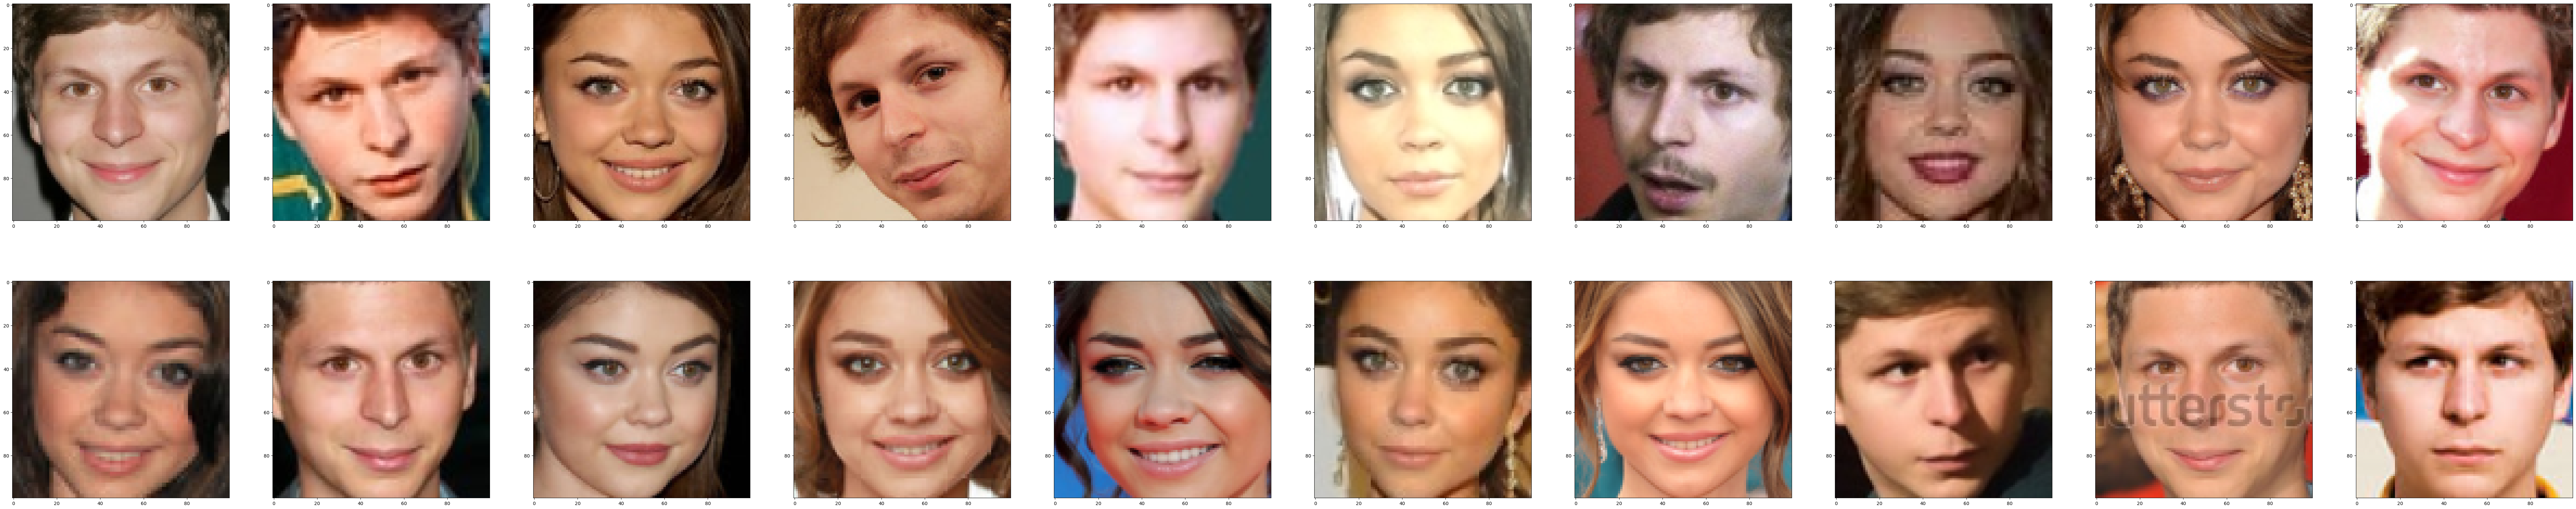

In [9]:
# plot faces of Michael and Sarah

plot_image_sequence(train_X[train_y == 0], n=20, imgs_per_row=10)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-9223372036854775808..-9223372036854775808].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-9223372036854775808..-9223372036854775808].


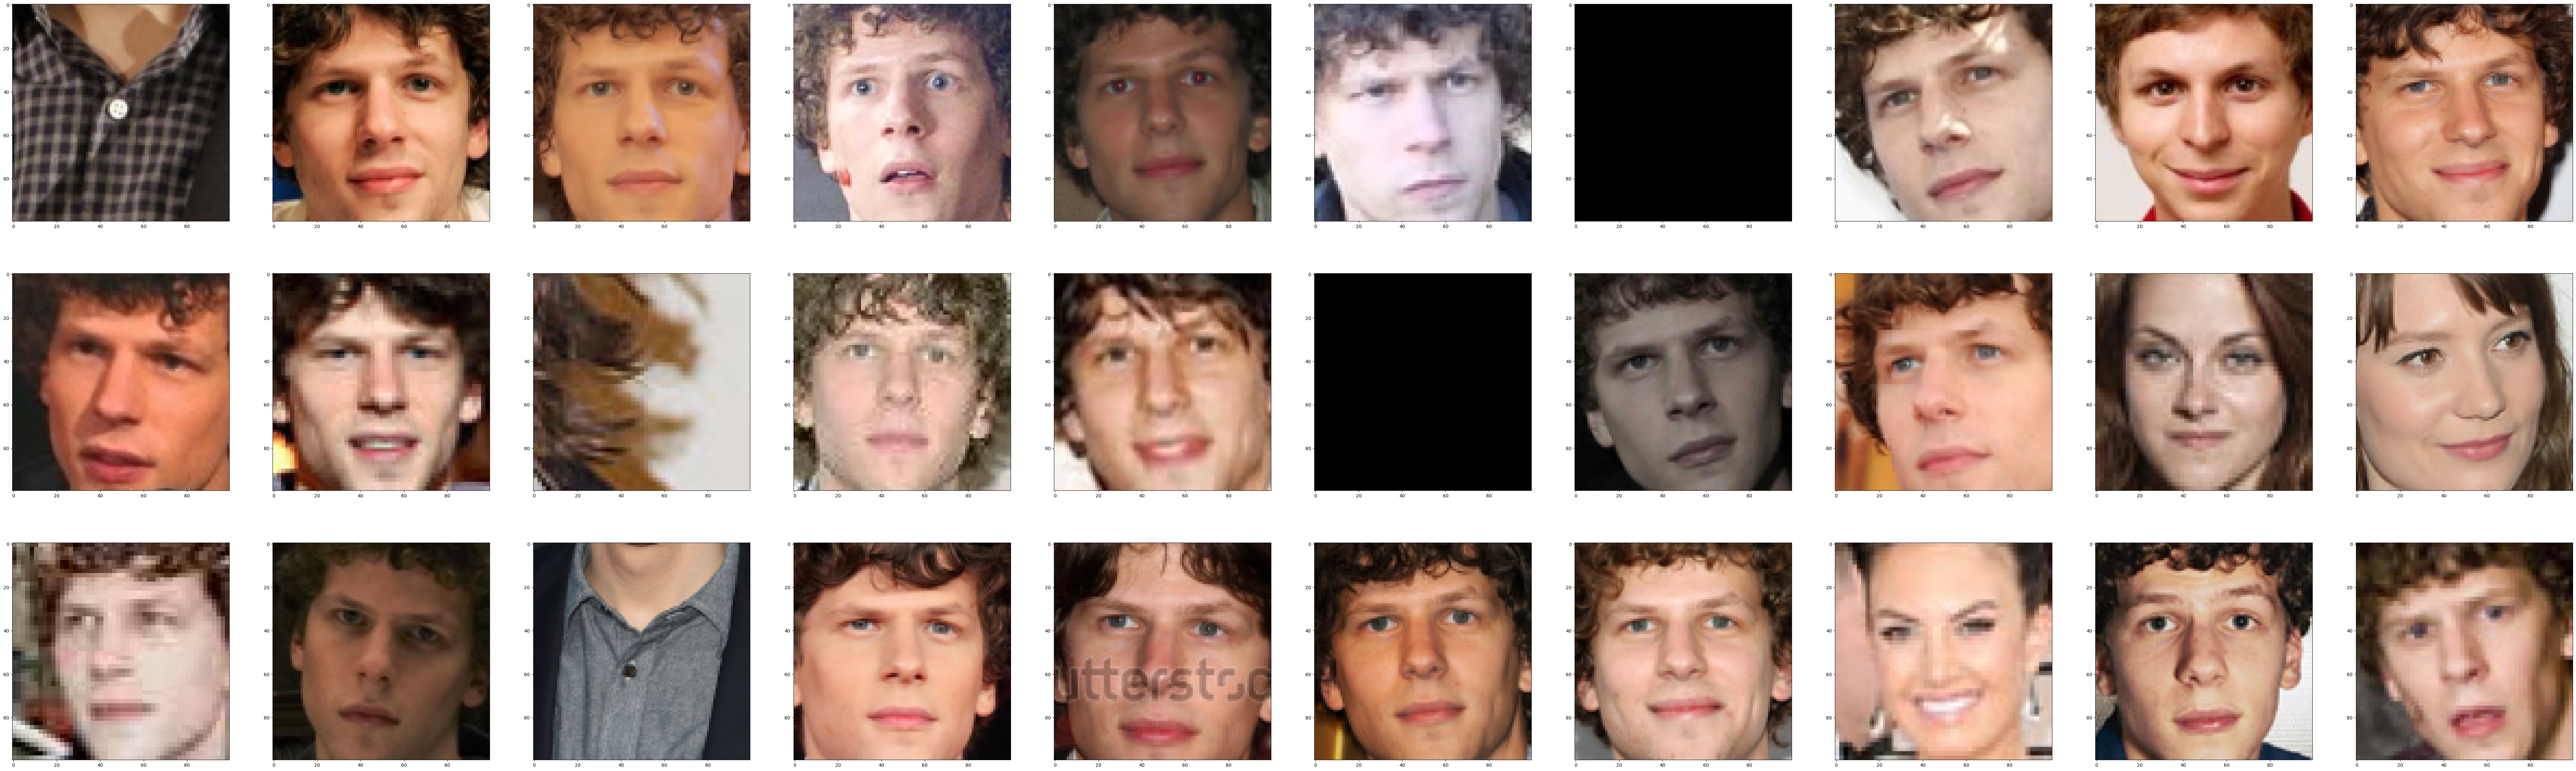

In [10]:
# plot faces of Jesse

plot_image_sequence(train_X[train_y == 1], n=30, imgs_per_row=10)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-9223372036854775808..-9223372036854775808].


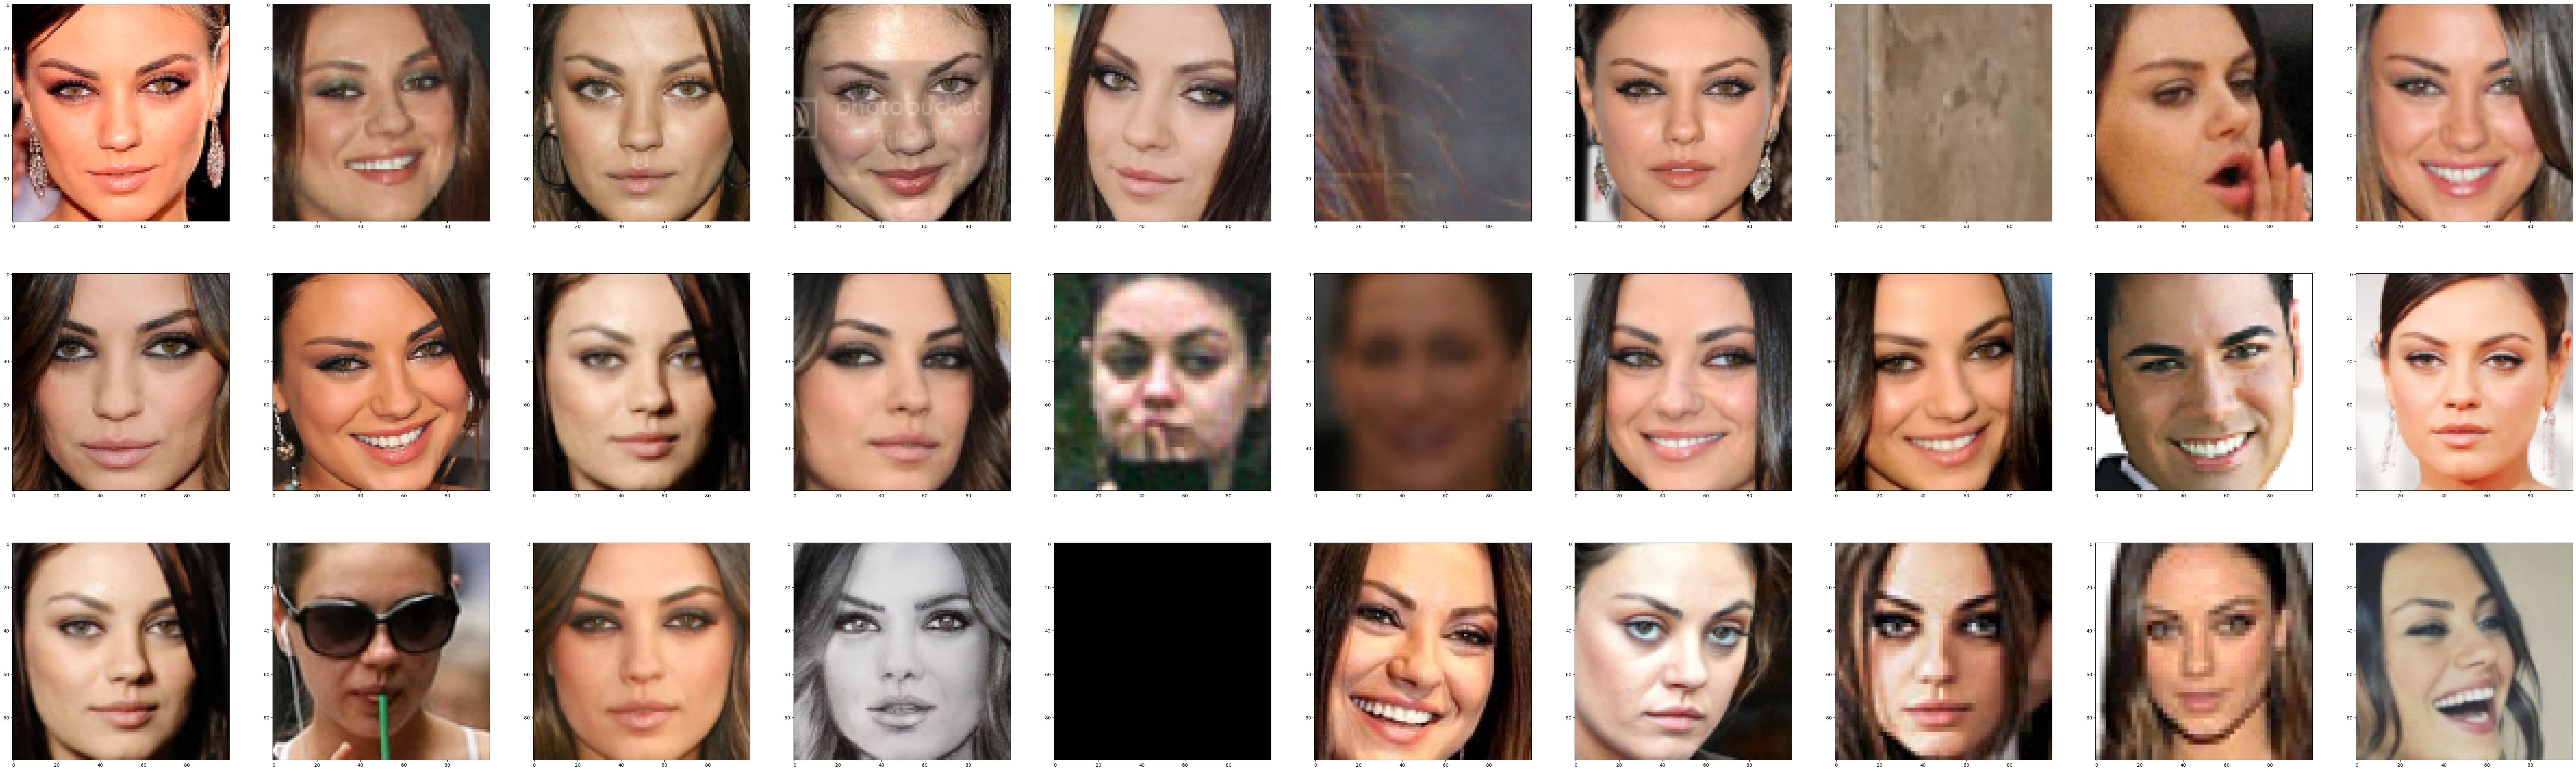

In [11]:
# plot faces of Mila

plot_image_sequence(train_X[train_y == 2], n=30, imgs_per_row=10)

## 0.4. Store Preprocessed data (optional)
<div class="alert alert-block alert-info">
<b>NOTE:</b> You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All". Feel free to use this to store intermediary results.
</div>

In [12]:
# save preprocessed data
# prep_path = '/kaggle/working/prepped_data/'
# if not os.path.exists(prep_path):
#     os.mkdir(prep_path)
    
# np.save(os.path.join(prep_path, 'train_X.npy'), train_X)
# np.save(os.path.join(prep_path, 'train_y.npy'), train_y)
# np.save(os.path.join(prep_path, 'test_X.npy'), test_X)

# load preprocessed data
# prep_path = '/kaggle/working/prepped_data/'
# if not os.path.exists(prep_path):
#     os.mkdir(prep_path)
# train_X = np.load(os.path.join(prep_path, 'train_X.npy'))
# train_y = np.load(os.path.join(prep_path, 'train_y.npy'))
# test_X = np.load(os.path.join(prep_path, 'test_X.npy'))

Now we are ready to rock!

# 1. Feature Representations
## 1.0. Example: Identify feature extractor
Our example feature extractor doesn't actually do anything... It just returns the input:
$$
\forall x : f(x) = x.
$$

It does make for a good placeholder and baseclass ;).

In [13]:
class IdentityFeatureExtractor:
    """A simple function that returns the input"""
    
    def transform(self, X):
        return X
    
    def __call__(self, X):
        return self.transform(X)

## 1.1. Baseline 1: HOG feature extractor/Scale Invariant Feature Transform
...

In [14]:
class HOGFeatureExtractor(IdentityFeatureExtractor):
    """TODO: this feature extractor is under construction"""
    
    def __init__(**params):
        self.params = params
        
    def transform(self, X):
        raise NotImplmentedError

### 1.1.1. t-SNE Plots
...

### 1.1.2. Discussion
...

## 1.2. Baseline 2: PCA feature extractor
...

In [50]:
class PCAFeatureExtractor(IdentityFeatureExtractor):
    """
    PCA feature extractor for face images.
    Input:
        X: shape (N, H, W) or (N, H, W, C)
    Output:
        PCA scores: shape (N, p)
    """

    def __init__(self, n_components=None, color_mode="gray", channel_order="BGR"):
        self.n_components = n_components
        self.color_mode = color_mode          # "gray" or "keep"
        self.channel_order = channel_order    # "BGR" or "RGB"

        self.pca_ = None
        self.mean_ = None
        self.components_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None
        self.singular_values_ = None
        self.image_shape_ = None
        self.n_features_ = None
        self.n_samples_ = None
        self.n_nonzero_ = None
        self.is_fitted_ = False

    def _to_gray(self, X):
        X = np.asarray(X, dtype=np.uint8)

        if X.ndim == 4:
            if self.color_mode == "gray":
                code = cv2.COLOR_BGR2GRAY if self.channel_order == "BGR" else cv2.COLOR_RGB2GRAY
                X = np.array([cv2.cvtColor(img, code) for img in X], dtype=np.float32)
            elif self.color_mode == "keep":
                pass
            else:
                raise ValueError("color_mode must be 'gray' or 'keep'")

        elif X.ndim == 3:
            # already grayscale batch: (N, H, W)
            pass
        else:
            raise ValueError("X must have shape (N, H, W) or (N, H, W, C)")

        return X

    def _flatten(self, X):
        X_proc = self._to_gray(X)
        return X_proc.reshape(X_proc.shape[0], -1), X_proc.shape[1:]

    def fit(self, X):
        X_flat, img_shape = self._flatten(X)

        self.image_shape_ = img_shape
        self.n_samples_, self.n_features_ = X_flat.shape

        self.pca_ = PCA(n_components=self.n_components)
        self.pca_.fit(X_flat)

        self.mean_ = self.pca_.mean_.reshape(1, -1)
        self.components_ = self.pca_.components_
        self.explained_variance_ = self.pca_.explained_variance_
        self.explained_variance_ratio_ = self.pca_.explained_variance_ratio_
        self.singular_values_ = self.pca_.singular_values_

        eps = 1e-10
        self.n_nonzero_ = int(np.sum(self.explained_variance_ > eps))

        self.is_fitted_ = True
        return self

    def transform(self, X):
        if not self.is_fitted_:
            raise ValueError("Call fit() before transform().")

        X_flat, _ = self._flatten(X)
        return self.pca_.transform(X_flat)

    def fit_transform(self, X):
        X_flat, img_shape = self._flatten(X)

        self.image_shape_ = img_shape
        self.n_samples_, self.n_features_ = X_flat.shape

        self.pca_ = PCA(n_components=self.n_components)
        Z = self.pca_.fit_transform(X_flat)

        self.mean_ = self.pca_.mean_.reshape(1, -1)
        self.components_ = self.pca_.components_
        self.explained_variance_ = self.pca_.explained_variance_
        self.explained_variance_ratio_ = self.pca_.explained_variance_ratio_
        self.singular_values_ = self.pca_.singular_values_

        eps = 1e-10
        self.n_nonzero_ = int(np.sum(self.explained_variance_ > eps))

        self.is_fitted_ = True
        return Z

    def inverse_transform(self, Z):
        if not self.is_fitted_:
            raise ValueError("Call fit() before inverse_transform().")

        Z = np.asarray(Z, dtype=np.float32)
        X_recon = self.pca_.inverse_transform(Z)
        return X_recon.reshape((Z.shape[0],) + self.image_shape_)

    def reconstruct_with_k(self, X, k):
        if not self.is_fitted_:
            raise ValueError("Call fit() before reconstruct_with_k().")

        X_flat, _ = self._flatten(X)
        k = min(k, self.components_.shape[0])

        X_centered = X_flat - self.mean_
        Zk = X_centered @ self.components_[:k].T
        X_recon = Zk @ self.components_[:k] + self.mean_

        return X_recon.reshape((X_flat.shape[0],) + self.image_shape_)

    def __call__(self, X):
        return self.transform(X)

flat_img min: 0.0
flat_img max: 255.0
flat_img mean: 120.10564
mean_face min: 49.575
mean_face max: 185.9625
mean_face mean: 120.10564


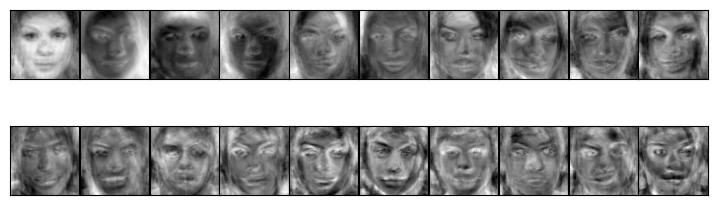

In [ ]:

# Step 1: fit full PCA on train set
data_train = np.copy(train_X)
pca = PCAFeatureExtractor(n_components=80, color_mode="gray", channel_order="RGB")

flat_img, img_shape = pca._flatten(data_train)

faces_pca = PCA(n_components=80)
faces_pca.fit(flat_img)

print("flat_img min:", flat_img.min())
print("flat_img max:", flat_img.max())
print("flat_img mean:", flat_img.mean())

mean_face = faces_pca.mean_.reshape(100, 100)
print("mean_face min:", mean_face.min())
print("mean_face max:", mean_face.max())
print("mean_face mean:", mean_face.mean())

fig, axes = plt.subplots(2,10,figsize=(9,3),
subplot_kw={'xticks':[], 'yticks':[]},
gridspec_kw=dict(hspace=0.01, wspace=0.01))
for i, ax in enumerate(axes.flat):
    ax.imshow(faces_pca.components_[i].reshape(100,100),cmap="gray")
plt.show()


In [ ]:
# train_Z = pca.fit(train_X)
# # test_Z = pca.transform(test_X)

# fig, axes = plt.subplots(2,1,figsize=(9,3), subplot_kw={'xticks':[], 'yticks':[]}, gridspec_kw=dict(hspace=0.01, wspace=0.01))
# for i, ax in enumerate(axes.flat):
#     ax.imshow(pca.components_[i].reshape(100,100),cmap='gray')

# pca_full = PCAFeatureExtractor(n_components=None)
# pca_full.fit(train_X)

# plot_eigenvalues(pca_full)

# # Step 2: choose p
# p, cumulative_var = choose_p_by_variance(
#     pca_full.explained_variance_ratio_,
#     threshold=0.95
# )

# print("Chosen p =", p)
# print("Non-zero eigenvalues =", pca_full.n_nonzero_)

In [ ]:
# Step 3: refit PCA with chosen p
pca_extractor = PCAFeatureExtractor(n_components=p)
train_X_pca = pca_extractor.fit_transform(train_X)
test_X_pca = pca_extractor.transform(test_X)

X_centered shape: (80, 100, 100)
components_ shape: (80, 100, 100)


C:\Users\sahil\AppData\Local\Temp\ipykernel_11928\2849471534.py:56: RuntimeWarning: overflow encountered in square
  all_explained_variance = (S ** 2) / (self.n_samples_ - 1)
C:\Users\sahil\AppData\Local\Temp\ipykernel_11928\2849471534.py:64: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var


ValueError: operands could not be broadcast together with remapped shapes [original->remapped]: (80,100,100)->(80,newaxis,newaxis) (100,100,80)->(100,newaxis,newaxis)  and requested shape (100,80)

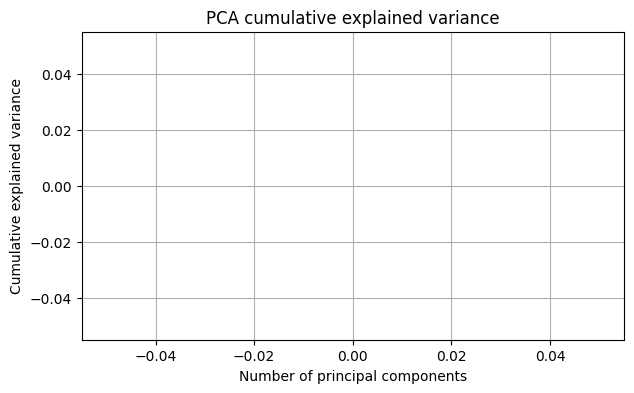

In [ ]:
plot_cumulative_variance(cumulative_var)

In [ ]:
def show_reconstruction_progression(pca, X, image_index=0, ks=[1, 5, 10, 20, 50]):
    original = X[image_index:image_index+1]

    ncols = len(ks) + 1
    plt.figure(figsize=(3*ncols, 3))

    # original
    plt.subplot(1, ncols, 1)
    img = original[0]
    if img.ndim == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(np.clip(img, 0, 1))
    plt.title("Original")
    plt.axis("off")

    for i, k in enumerate(ks, start=2):
        recon = pca.reconstruct_with_k(original, k)[0]
        plt.subplot(1, ncols, i)
        if recon.ndim == 2:
            plt.imshow(recon, cmap='gray')
        else:
            plt.imshow(np.clip(recon, 0, 1))
        plt.title(f"k = {k}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

def show_eigenfaces(pca, n_faces=10):
    n_faces = min(n_faces, pca.components_.shape[0])
    plt.figure(figsize=(2*n_faces, 2))

    for i in range(n_faces):
        eigenface = pca.components_[i].reshape(pca.image_shape_)

        plt.subplot(1, n_faces, i + 1)
        if eigenface.ndim == 2:
            plt.imshow(eigenface, cmap='gray')
        else:
            ef = eigenface - eigenface.min()
            ef = ef / (ef.max() + 1e-8)
            plt.imshow(ef)
        plt.title(f"PC {i+1}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

C:\Users\sahil\AppData\Local\Temp\ipykernel_11928\4229130009.py:54: RuntimeWarning: overflow encountered in square
  all_explained_variance = (S ** 2) / (self.n_samples_ - 1)
C:\Users\sahil\AppData\Local\Temp\ipykernel_11928\4229130009.py:62: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var


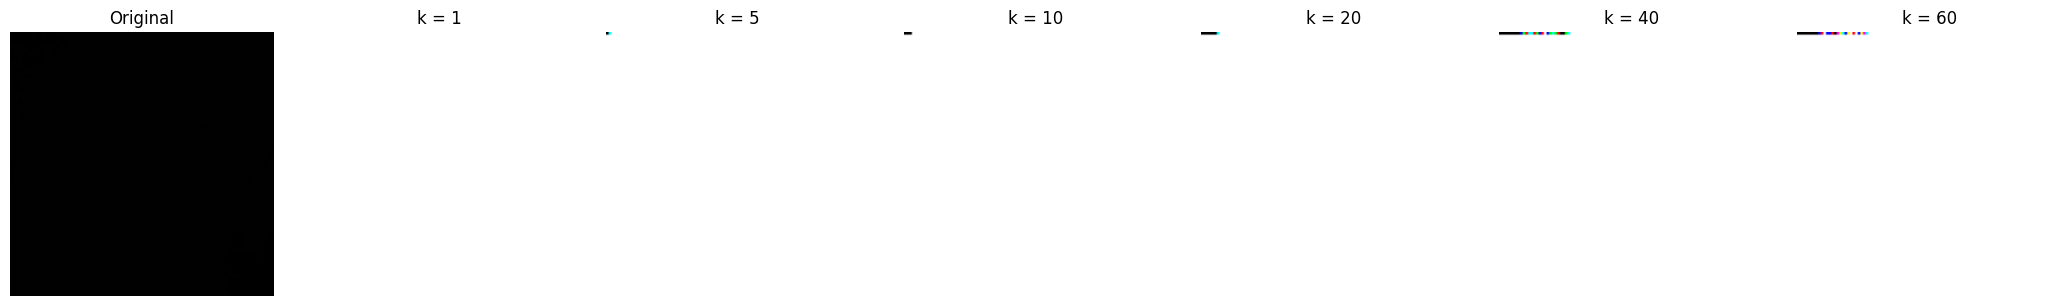

In [ ]:
# Fit with enough components first
pca_vis = PCAFeatureExtractor(n_components=None)
pca_vis.fit(train_X)

show_reconstruction_progression(
    pca_vis,
    train_X,
    image_index=0,
    ks=[1, 5, 10, 20, 40, 60]
)

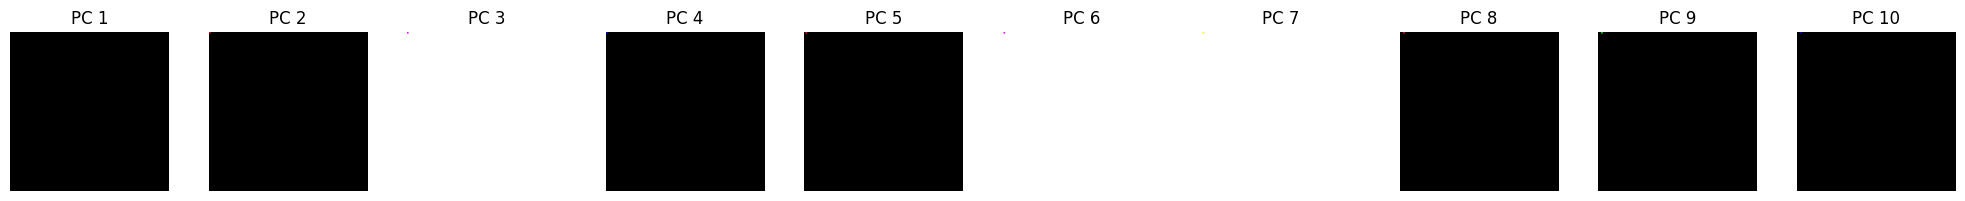

In [ ]:
show_eigenfaces(pca_vis, n_faces=10)

In [ ]:
def plot_pca_2d(Z, y, label_names=None):
    plt.figure(figsize=(7, 6))
    classes = np.unique(y)

    for c in classes:
        idx = (y == c)
        name = str(c) if label_names is None else label_names.get(c, str(c))
        plt.scatter(Z[idx, 0], Z[idx, 1], label=name, alpha=0.8)

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Faces projected onto first two principal components")
    plt.legend()
    plt.grid(True)
    plt.show()

C:\Users\sahil\AppData\Local\Temp\ipykernel_11928\4229130009.py:54: RuntimeWarning: overflow encountered in square
  all_explained_variance = (S ** 2) / (self.n_samples_ - 1)
C:\Users\sahil\AppData\Local\Temp\ipykernel_11928\4229130009.py:62: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var


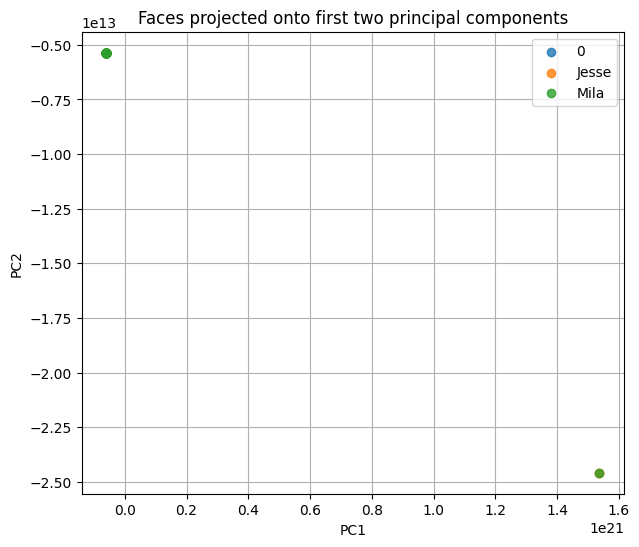

In [ ]:
# fit PCA with at least 2 comps
pca_2d = PCAFeatureExtractor(n_components=max(p, 2))
train_Z = pca_2d.fit_transform(train_X)

plot_pca_2d(
    train_Z,
    train_y,
    label_names={1: "Jesse", 2: "Mila", 3: "Other"}
)

In [ ]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

def plot_faces_in_pca_space(Z, X, zoom=0.35, max_points=None):
    if max_points is not None:
        Z = Z[:max_points]
        X = X[:max_points]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_title("Faces in first two PCA dimensions")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

    ax.scatter(Z[:, 0], Z[:, 1], alpha=0.1)

    for i in range(len(Z)):
        img = X[i]
        if img.ndim == 2:
            imagebox = OffsetImage(img, cmap='gray', zoom=zoom)
        else:
            imagebox = OffsetImage(np.clip(img, 0, 1), zoom=zoom)
        ab = AnnotationBbox(imagebox, (Z[i, 0], Z[i, 1]), frameon=False)
        ax.add_artist(ab)

    plt.show()

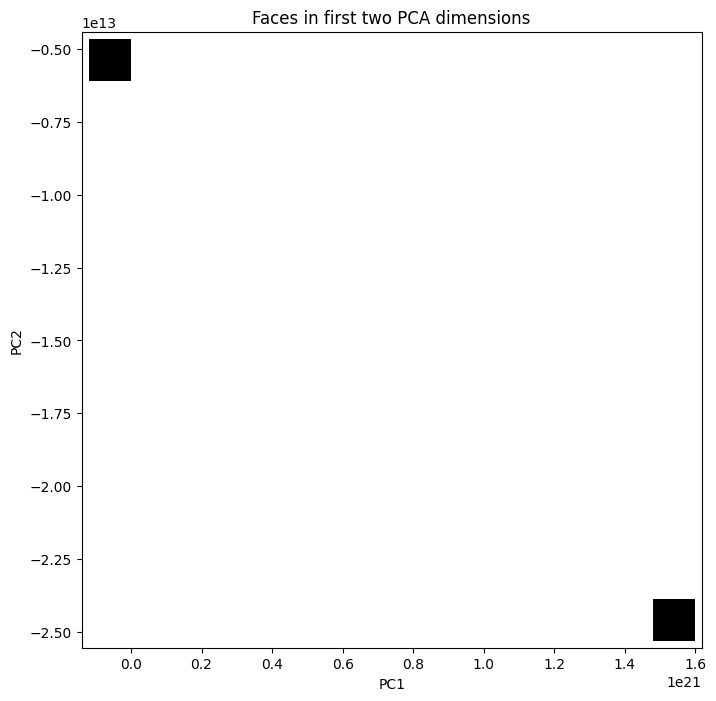

In [ ]:
plot_faces_in_pca_space(train_Z[:, :2], train_X, zoom=0.3, max_points=80)

### 1.2.1. Eigenface Plots
...

### 1.2.2. Feature Space Plots
...

### 1.2.3. Discussion
...

# 2. Evaluation Metrics
## 2.0. Example: Accuracy
As example metric we take the accuracy. Informally, accuracy is the proportion of correct predictions over the total amount of predictions. It is used a lot in classification but it certainly has its disadvantages...

In [ ]:
from sklearn.metrics import accuracy_score

# 3. Classifiers
## 3.0. Example: The *'not so smart'* classifier
This random classifier is not very complicated. It makes predictions at random, based on the distribution obseved in the training set. **It thus assumes** that the class labels of the test set will be distributed similarly to the training set.

In [ ]:
class RandomClassificationModel:
    """Random classifier, draws a random sample based on class distribution observed 
    during training."""
    
    def fit(self, X, y):
        """Adjusts the class ratio instance variable to the one observed in y. 

        Parameters
        ----------
        X : tensor
            Training set
        y : array
            Training set labels

        Returns
        -------
        self : RandomClassificationModel
        """
        
        self.classes, self.class_ratio = np.unique(y, return_counts=True)
        self.class_ratio = self.class_ratio / self.class_ratio.sum()
        return self
        
    def predict(self, X):
        """Samples labels for the input data. 

        Parameters
        ----------
        X : tensor
            dataset
            
        Returns
        -------
        y_star : array
            'Predicted' labels
        """

        np.random.seed(0)
        return np.random.choice(self.classes, size = X.shape[0], p=self.class_ratio)
    
    def __call__(self, X):
        return self.predict(X)
    

## 3.1. Baseline 1: My favorite classifier
...

In [ ]:
class FavoriteClassificationModel:
    """TODO: this classifier is under construction."""
    
    def fit(self, X, y):
        raise NotImplmentedError
        
    def predict(self, X):
        raise NotImplmentedError

# 4. Experiments
<div class="alert alert-block alert-info"> <b>NOTE:</b> Do <i>NOT</i> use this section to keep track of every little change you make in your code! Instead, highlight the most important findings and the major (best) pipelines that you've discovered.  
</div>
<br>

## 4.0. Example: basic pipeline
The basic pipeline takes any input and samples a label based on the class label distribution of the training set. As expected the performance is very poor, predicting approximately 1/4 correctly on the training set. There is a lot of room for improvement but this is left to you ;). 

In [ ]:
feature_extractor = IdentityFeatureExtractor() 
classifier = RandomClassificationModel()

# train the model on the features
classifier.fit(feature_extractor(train_X), train_y)

# model/final pipeline
model = lambda X: classifier(feature_extractor(X))

In [ ]:
# evaluate performance of the model on the training set
train_y_star = model(train_X)

"The performance on the training set is {:.2f}. This however, does not tell us much about the actual performance (generalisability).".format(
    accuracy_score(train_y, train_y_star))

In [ ]:
# predict the labels for the test set 
test_y_star = model(test_X)

# 5. Publishing best results

In [ ]:
submission = test.copy().drop('img', axis = 1)
submission['class'] = test_y_star

submission

In [ ]:
submission.to_csv('submission.csv')

# 6. Discussion
...

In summary we contributed the following: 
* 
